In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/spotify-music-dataset/low_popularity_spotify_data.csv
/kaggle/input/spotify-music-dataset/high_popularity_spotify_data.csv


In [2]:
# =========================
# ✅ One-cell 可跑版本（自動適配 popularity / track_popularity）
# ✅ 目標：提高 accuracy（極端標籤 + 丟掉模糊區 + 調參）
# =========================
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ========= 1) 讀資料 =========
# 你們現在這份看起來是「單一 CSV」類型（有 track_popularity、track_name 等）
# 如果你們是用 Kaggle 右側 Data 直接掛的檔案，把檔名改成那個 csv 的名字即可
# 例：DATA_PATH = "/kaggle/input/xxx/spotify.csv"
DATA_PATH = None

if DATA_PATH is not None:
    df = pd.read_csv(DATA_PATH)
else:
    # 如果你們仍然是 high/low 那份資料集，就用這段（兩個檔案合併）
    HIGH_PATH = "/kaggle/input/spotify-music-dataset/high_popularity_spotify_data.csv"
    LOW_PATH  = "/kaggle/input/spotify-music-dataset/low_popularity_spotify_data.csv"
    high = pd.read_csv(HIGH_PATH)
    low  = pd.read_csv(LOW_PATH)
    df = pd.concat([high, low], ignore_index=True)

print("✅ df shape:", df.shape)
print("✅ columns preview:", list(df.columns)[:30])

# ========= 2) 找「熱門度欄位」(關鍵修正) =========
pop_col_candidates = ["popularity", "track_popularity"]
pop_col = next((c for c in pop_col_candidates if c in df.columns), None)
if pop_col is None:
    raise ValueError(f"找不到熱門度欄位（popularity / track_popularity）。目前欄位有：{list(df.columns)[:50]}")

df[pop_col] = pd.to_numeric(df[pop_col], errors="coerce")

# ========= 3) 定義 is_hit（提高準確率核心：前15% vs 後15%，丟掉中間） =========
top_q = 0.90  # 前15%
bot_q = 0.10  # 後15%

hit_th = df[pop_col].quantile(top_q)
low_th = df[pop_col].quantile(bot_q)

df = df[(df[pop_col] >= hit_th) | (df[pop_col] <= low_th)].copy()
df["is_hit"] = (df[pop_col] >= hit_th).astype(int)

print(f"✅ 使用熱門度欄位：{pop_col}")
print(f"✅ 熱門門檻 (top {int((1-top_q)*100)}%) >= {hit_th:.2f}")
print(f"✅ 冷門門檻 (bottom {int(bot_q*100)}%) <= {low_th:.2f}")
print("✅ y 分布:", df["is_hit"].value_counts().to_dict())

# ========= 4) 選特徵（只用數值 audio features） =========
candidate_features = [
    "danceability","energy","valence","tempo","loudness","acousticness",
    "speechiness","instrumentalness","liveness"
]
features = [c for c in candidate_features if c in df.columns]
if len(features) < 2:
    raise ValueError(f"可用 features 太少：{features}，請確認資料欄位。")

X = df[features].apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(df["is_hit"], errors="coerce")

data = pd.concat([X, y.rename("is_hit")], axis=1)
data = data.replace([np.inf, -np.inf], np.nan).dropna()
X = data[features]
y = data["is_hit"].astype(int)

print("✅ 清理後 X:", X.shape, "| y:", y.value_counts().to_dict())
print("✅ 使用 features:", features)

# ========= 5) 切 train/test =========
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ========= 6) Logistic Regression（標準化 + balanced） =========
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=3000, class_weight="balanced")
lr.fit(X_train_s, y_train)
lr_pred = lr.predict(X_test_s)

print("\n=========================")
print("📌 Logistic Regression")
print("=========================")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, lr_pred))
print("Report:\n", classification_report(y_test, lr_pred))
# ========= LR Feature Importance（用係數 coef_）=========
lr_imp = pd.Series(
    lr.coef_[0],          # 每個特徵的權重
    index=features
).sort_values(key=np.abs, ascending=False)  # 依影響力(絕對值)排序

print("\n⭐ LR Feature Importance (Coefficients):\n", lr_imp)

# 如果你想同時看「方向」（正→更像熱門、負→更像不熱門）
print("\n⭐ LR Coef sign meaning: + => more likely hit, - => less likely hit")


# ========= 7) Random Forest（調參 + balanced） =========
rf = RandomForestClassifier(
    n_estimators=800,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("\n=========================")
print("🌲 Random Forest")
print("=========================")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_pred))
print("Report:\n", classification_report(y_test, rf_pred))
imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
print("\n⭐ RF Feature Importance:\n", imp)


# ========= 8) Gradient Boosting =========
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

print("\n=========================")
print("🚀 Gradient Boosting")
print("=========================")
print("Accuracy:", accuracy_score(y_test, gb_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, gb_pred))
print("Report:\n", classification_report(y_test, gb_pred))
gb_imp = pd.Series(gb.feature_importances_, index=features).sort_values(ascending=False)
print("\n⭐ GB Feature Importance:\n", gb_imp)

✅ df shape: (4831, 29)
✅ columns preview: ['energy', 'tempo', 'danceability', 'playlist_genre', 'loudness', 'liveness', 'valence', 'track_artist', 'time_signature', 'speechiness', 'track_popularity', 'track_href', 'uri', 'track_album_name', 'playlist_name', 'analysis_url', 'track_id', 'track_name', 'track_album_release_date', 'instrumentalness', 'track_album_id', 'mode', 'key', 'duration_ms', 'acousticness', 'id', 'playlist_subgenre', 'type', 'playlist_id']
✅ 使用熱門度欄位：track_popularity
✅ 熱門門檻 (top 9%) >= 78.00
✅ 冷門門檻 (bottom 10%) <= 26.00
✅ y 分布: {1: 564, 0: 519}
✅ 清理後 X: (1083, 9) | y: {1: 564, 0: 519}
✅ 使用 features: ['danceability', 'energy', 'valence', 'tempo', 'loudness', 'acousticness', 'speechiness', 'instrumentalness', 'liveness']

📌 Logistic Regression
Accuracy: 0.7327188940092166
Confusion Matrix:
 [[69 35]
 [23 90]]
Report:
               precision    recall  f1-score   support

           0       0.75      0.66      0.70       104
           1       0.72      0.80      0.76   

LR AUC: 0.7975663716814159
RF AUC: 0.8196051735874745
GB AUC: 0.8137338325391423


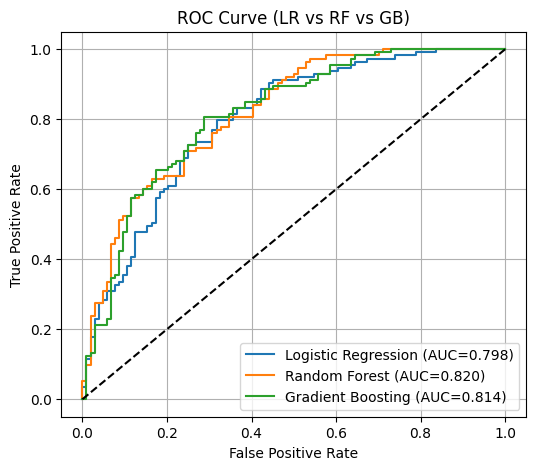

In [3]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 1) 各模型「正類(=1)機率/分數」
lr_score = lr.predict_proba(X_test_s)[:, 1]      # LR 用標準化後的 X_test_s
rf_score = rf.predict_proba(X_test)[:, 1]        # RF 用原本的 X_test

# GB：通常有 predict_proba；若沒有就用 decision_function
if hasattr(gb, "predict_proba"):
    gb_score = gb.predict_proba(X_test)[:, 1]
else:
    gb_score = gb.decision_function(X_test)

# 2) AUC 數值
print("LR AUC:", roc_auc_score(y_test, lr_score))
print("RF AUC:", roc_auc_score(y_test, rf_score))
print("GB AUC:", roc_auc_score(y_test, gb_score))

# 3) ROC 曲線（同圖比較）
def add_roc(y_true, y_score, name):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc_val = roc_auc_score(y_true, y_score)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")

plt.figure(figsize=(6,5))
add_roc(y_test, lr_score, "Logistic Regression")
add_roc(y_test, rf_score, "Random Forest")
add_roc(y_test, gb_score, "Gradient Boosting")

plt.plot([0, 1], [0, 1], "k--")  # 隨機基準線
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (LR vs RF vs GB)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [4]:
from sklearn.metrics import confusion_matrix

def get_tp_fp_fn_tn(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tp, fp, fn, tn


In [5]:
tp_lr, fp_lr, fn_lr, tn_lr = get_tp_fp_fn_tn(y_test, lr_pred)

print("📌 Logistic Regression")
print("TP:", tp_lr, "FP:", fp_lr, "FN:", fn_lr, "TN:", tn_lr)
tp_rf, fp_rf, fn_rf, tn_rf = get_tp_fp_fn_tn(y_test, rf_pred)

print("🌲 Random Forest")
print("TP:", tp_rf, "FP:", fp_rf, "FN:", fn_rf, "TN:", tn_rf)
tp_gb, fp_gb, fn_gb, tn_gb = get_tp_fp_fn_tn(y_test, gb_pred)

print("🚀 Gradient Boosting")
print("TP:", tp_gb, "FP:", fp_gb, "FN:", fn_gb, "TN:", tn_gb)


📌 Logistic Regression
TP: 90 FP: 35 FN: 23 TN: 69
🌲 Random Forest
TP: 86 FP: 33 FN: 27 TN: 71
🚀 Gradient Boosting
TP: 88 FP: 30 FN: 25 TN: 74


In [6]:
print("總資料筆數:", X.shape[0])
print("訓練集筆數:", X_train.shape[0])
print("測試集筆數:", X_test.shape[0])


總資料筆數: 1083
訓練集筆數: 866
測試集筆數: 217


In [7]:
from sklearn.metrics import confusion_matrix

def confusion_percent(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    total = tn + fp + fn + tp

    return {
        "TP": tp / total * 100,
        "FP": fp / total * 100,
        "FN": fn / total * 100,
        "TN": tn / total * 100,
        "Total": (tp + fp + fn + tn) / total * 100
    }

rf_pct = confusion_percent(y_test, rf_pred)
print("🌲 Random Forest 百分比：")
for k, v in rf_pct.items():
    print(f"{k}: {v:.2f}%")
lr_pct = confusion_percent(y_test, lr_pred)
print("📌 Logistic Regression 百分比：")
for k, v in lr_pct.items():
    print(f"{k}: {v:.2f}%")
gb_pct = confusion_percent(y_test, gb_pred)
print("🚀 Gradient Boosting 百分比：")
for k, v in gb_pct.items():
    print(f"{k}: {v:.2f}%")


🌲 Random Forest 百分比：
TP: 39.63%
FP: 15.21%
FN: 12.44%
TN: 32.72%
Total: 100.00%
📌 Logistic Regression 百分比：
TP: 41.47%
FP: 16.13%
FN: 10.60%
TN: 31.80%
Total: 100.00%
🚀 Gradient Boosting 百分比：
TP: 40.55%
FP: 13.82%
FN: 11.52%
TN: 34.10%
Total: 100.00%


In [8]:
from sklearn.metrics import roc_curve

# 1️⃣ 先算「預測為熱門歌的機率」
rf_proba = rf.predict_proba(X_test)[:, 1]

# 2️⃣ 再算 ROC
fpr, tpr, thresholds = roc_curve(y_test, rf_proba)

# 3️⃣ 找最佳 threshold（Youden's J）
best_idx = (tpr - fpr).argmax()
best_threshold = thresholds[best_idx]

print("✅ Best threshold:", best_threshold)


✅ Best threshold: 0.5479506983647151


In [9]:
print("rf_proba shape:", rf_proba.shape)


rf_proba shape: (217,)


In [10]:
rf_pred_best = (rf_proba >= best_threshold).astype(int)


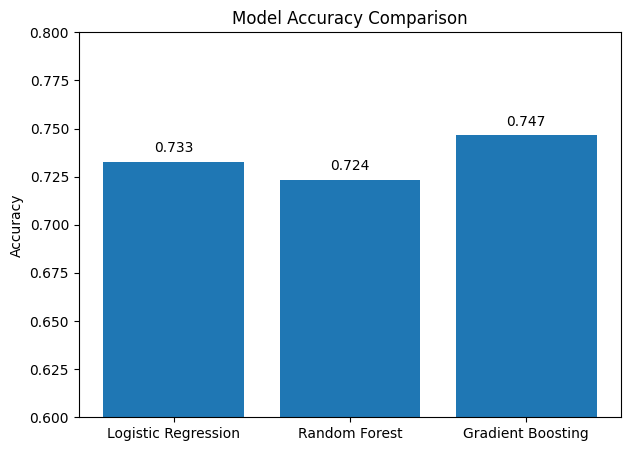

In [11]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Random Forest", "Gradient Boosting"]
accuracies = [0.7327, 0.7235, 0.7465]

plt.figure(figsize=(7,5))
plt.bar(models, accuracies)
plt.ylim(0.6, 0.8)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.005, f"{v:.3f}", ha="center")
plt.show()


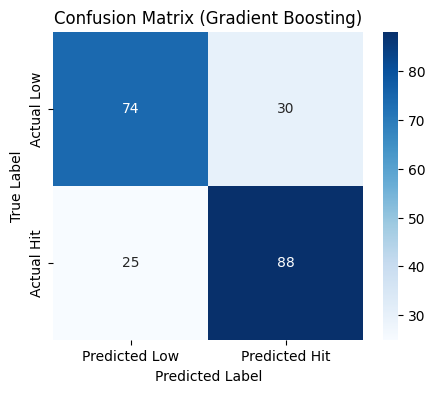

In [12]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, gb_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted Low", "Predicted Hit"],
            yticklabels=["Actual Low", "Actual Hit"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Gradient Boosting)")
plt.show()
